In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip /content/drive/MyDrive/OMR-Datasets/OMR_5Fold_ROIs_split_v3.zip

Streaming output truncated to the last 5000 lines.
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_50_1_box9.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam2_67_1_box24.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam4_52_1_box6.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_83_1_box26.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_222_1_box15.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_47_1_box0.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_24_1_box40.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_128_1_box29.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_88_1_box36.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_190_1_box47.jpg  
  inflating: content/OMR_5Fold_ROIs_split/Fold_2/val/confirmed/exam5_57_1_box19.jpg  
  i

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.6 MB/s eta 0:00:00


#Yolo

## Scene 1

🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: YOLO TRÊN 5 FOLDS

[==================== ĐÁNH GIÁ FOLD 1 ====================]
✅ Fold 1 | Acc: 99.13% | Prec: 80.47% | Rec: 87.61% | F1: 83.25%

[==================== ĐÁNH GIÁ FOLD 2 ====================]
✅ Fold 2 | Acc: 99.53% | Prec: 91.75% | Rec: 88.27% | F1: 89.87%

[==================== ĐÁNH GIÁ FOLD 3 ====================]
✅ Fold 3 | Acc: 99.19% | Prec: 78.70% | Rec: 84.63% | F1: 81.05%

[==================== ĐÁNH GIÁ FOLD 4 ====================]
✅ Fold 4 | Acc: 99.45% | Prec: 89.64% | Rec: 85.86% | F1: 87.57%

[==================== ĐÁNH GIÁ FOLD 5 ====================]
✅ Fold 5 | Acc: 99.47% | Prec: 89.45% | Rec: 85.02% | F1: 86.98%

🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - YOLO 🏆
Accuracy : 99.35% ± 0.16%
Precision: 86.00% ± 5.33%
Recall   : 86.28% ± 1.43%
F1-Score : 85.75% ± 3.17%

📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):
              precision    recall  f1-score   support

   confirmed     0.9917    0.9925    0.9921

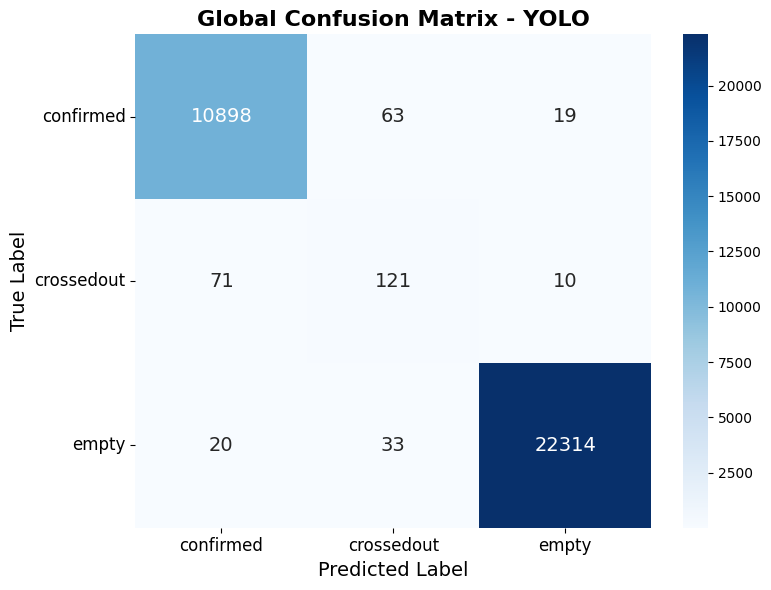

✅ Đã lưu ảnh ma trận nhầm lẫn tại 'global_confusion_matrix_yolo.png'


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from ultralytics import YOLO

# =============================================================================
# 1. CẤU HÌNH ĐÁNH GIÁ (BẠN CHỈ CHỈNH SỬA PHẦN NÀY)
# =============================================================================
# Lựa chọn mô hình muốn đánh giá: 'efficientnet', 'resnet50', hoặc 'yolo'
MODEL_TO_TEST = 'yolo'

# Thư mục gốc chứa 5 Fold (Bên trong là Fold_1, Fold_2... và mục con 'val' hoặc 'test')
BASE_FOLDS_DIR = "/content/content/OMR_5Fold_ROIs_split"
TEST_FOLDER_NAME = "test" # Đổi thành 'test' nếu lúc chia dữ liệu bạn đặt tên là test
W_DIR = "/content/drive/MyDrive/OMR-Datasets/train-cls/scene1/Yolo26s"

CLASS_NAMES = ['confirmed', 'crossedout', 'empty'] # Đảm bảo đúng chuẩn Alphabet
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# =============================================================================
# 2. ĐỊNH NGHĨA TIỀN XỬ LÝ (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, (255, 255, 255), 'constant')

data_transforms = transforms.Compose([
    SquarePad(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# =============================================================================
# 3. HÀM KHỞI TẠO MÔ HÌNH (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
def get_efficientnet_model():
    model = models.efficientnet_b0(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

def get_resnet50_model():
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

# =============================================================================
# 4. VÒNG LẶP ĐÁNH GIÁ 5 FOLD CHÍNH
# =============================================================================
def evaluate_all_folds():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: {MODEL_TO_TEST.upper()} TRÊN 5 FOLDS")

    fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    global_y_true = []
    global_y_pred = []

    for fold in range(1, 6):
        print(f"\n[{'='*20} ĐÁNH GIÁ FOLD {fold} {'='*20}]")

        fold_dir = os.path.join(BASE_FOLDS_DIR, f"Fold_{fold}")
        test_dir = os.path.join(fold_dir, TEST_FOLDER_NAME)
        weight_dir = os.path.join(W_DIR, f"Fold_{fold}")

        if not os.path.exists(test_dir):
            print(f"❌ Không tìm thấy dữ liệu Test tại {test_dir}. Bỏ qua Fold {fold}.")
            continue

        y_true_fold = []
        y_pred_fold = []

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO PYTORCH (EfficientNet & ResNet50)
        # ---------------------------------------------------------
        if MODEL_TO_TEST in ['efficientnet', 'resnet50']:
            # Lấy đường dẫn trọng số tốt nhất của Fold này
            # (Bạn sửa lại tên file trọng số cho khớp với lúc bạn lưu nhé)
            weight_name = f"{MODEL_TO_TEST}_b0_fold{fold}.pth"
            # weight_name = f"{MODEL_TO_TEST}_fold{fold}.pth"
            weight_path = os.path.join(weight_dir, weight_name)

            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy trọng số tại {weight_path}.")
                continue

            # Khởi tạo mô hình
            if MODEL_TO_TEST == 'efficientnet':
                model = get_efficientnet_model()
            else:
                model = get_resnet50_model()

            model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()

            # Load dữ liệu
            test_dataset = datasets.ImageFolder(test_dir, data_transforms)
            test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

            # Inference
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(DEVICE)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    y_true_fold.extend(labels.cpu().numpy())
                    y_pred_fold.extend(preds.cpu().numpy())

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO YOLOv8-cls
        # ---------------------------------------------------------
        elif MODEL_TO_TEST == 'yolo':
            weight_path = os.path.join(weight_dir, "weights", "best.pt")
            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy YOLO model tại {weight_path}.")
                continue

            model = YOLO(weight_path)

            # Dùng ImageFolder để đọc toàn bộ đường dẫn ảnh và nhãn thực tế một cách chuẩn xác
            test_dataset = datasets.ImageFolder(test_dir)

            for img_path, label_idx in test_dataset.samples:
                # YOLO tự động lo phần transform
                results = model(img_path, verbose=False)
                pred_idx = results[0].probs.top1 # Lấy index có xác suất cao nhất

                y_true_fold.append(label_idx)
                y_pred_fold.append(pred_idx)

        # ---------------------------------------------------------
        # TÍNH TOÁN CHỈ SỐ CỦA FOLD
        # ---------------------------------------------------------
        acc = accuracy_score(y_true_fold, y_pred_fold) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_fold, y_pred_fold, average='macro', zero_division=0
        )
        prec, rec, f1 = prec * 100, rec * 100, f1 * 100

        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)

        print(f"✅ Fold {fold} | Acc: {acc:.2f}% | Prec: {prec:.2f}% | Rec: {rec:.2f}% | F1: {f1:.2f}%")

        # Gom dữ liệu để đánh giá Global
        global_y_true.extend(y_true_fold)
        global_y_pred.extend(y_pred_fold)

    # =========================================================================
    # 5. XUẤT BÁO CÁO TỔNG KẾT & MA TRẬN NHẦM LẪN (DÀNH CHO BÀI BÁO)
    # =========================================================================
    if len(global_y_true) == 0:
        print("❌ Không có dữ liệu để đánh giá. Vui lòng kiểm tra lại đường dẫn.")
        return

    print(f"\n🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - {MODEL_TO_TEST.upper()} 🏆")
    print("=" * 60)
    print(f"Accuracy : {np.mean(fold_metrics['acc']):.2f}% ± {np.std(fold_metrics['acc']):.2f}%")
    print(f"Precision: {np.mean(fold_metrics['prec']):.2f}% ± {np.std(fold_metrics['prec']):.2f}%")
    print(f"Recall   : {np.mean(fold_metrics['rec']):.2f}% ± {np.std(fold_metrics['rec']):.2f}%")
    print(f"F1-Score : {np.mean(fold_metrics['f1']):.2f}% ± {np.std(fold_metrics['f1']):.2f}%")
    print("=" * 60)

    print("\n📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):")
    report = classification_report(global_y_true, global_y_pred, target_names=CLASS_NAMES, digits=4)
    print(report)

    # Vẽ và lưu Ma trận nhầm lẫn
    cm = confusion_matrix(global_y_true, global_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={"size": 14})

    plt.title(f'Global Confusion Matrix - {MODEL_TO_TEST.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)

    img_name = f'global_confusion_matrix_{MODEL_TO_TEST}.png'
    plt.tight_layout()
    plt.savefig(img_name, dpi=300) # Xuất ảnh 300 DPI cực nét
    plt.show()

    print(f"✅ Đã lưu ảnh ma trận nhầm lẫn tại '{img_name}'")

# Gọi hàm thực thi
if __name__ == '__main__':
    evaluate_all_folds()

## Scene 2

🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: YOLO TRÊN 5 FOLDS

[==================== ĐÁNH GIÁ FOLD 1 ====================]
✅ Fold 1 | Acc: 99.14% | Prec: 81.96% | Rec: 88.60% | F1: 84.65%

[==================== ĐÁNH GIÁ FOLD 2 ====================]
✅ Fold 2 | Acc: 99.56% | Prec: 90.46% | Rec: 90.97% | F1: 90.71%

[==================== ĐÁNH GIÁ FOLD 3 ====================]
✅ Fold 3 | Acc: 99.52% | Prec: 86.41% | Rec: 82.30% | F1: 84.10%

[==================== ĐÁNH GIÁ FOLD 4 ====================]
✅ Fold 4 | Acc: 99.39% | Prec: 84.82% | Rec: 84.90% | F1: 84.86%

[==================== ĐÁNH GIÁ FOLD 5 ====================]
✅ Fold 5 | Acc: 99.40% | Prec: 86.01% | Rec: 83.46% | F1: 84.64%

🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - YOLO 🏆
Accuracy : 99.40% ± 0.15%
Precision: 85.93% ± 2.75%
Recall   : 86.04% ± 3.25%
F1-Score : 85.79% ± 2.47%

📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):
              precision    recall  f1-score   support

   confirmed     0.9925    0.9929    0.9927

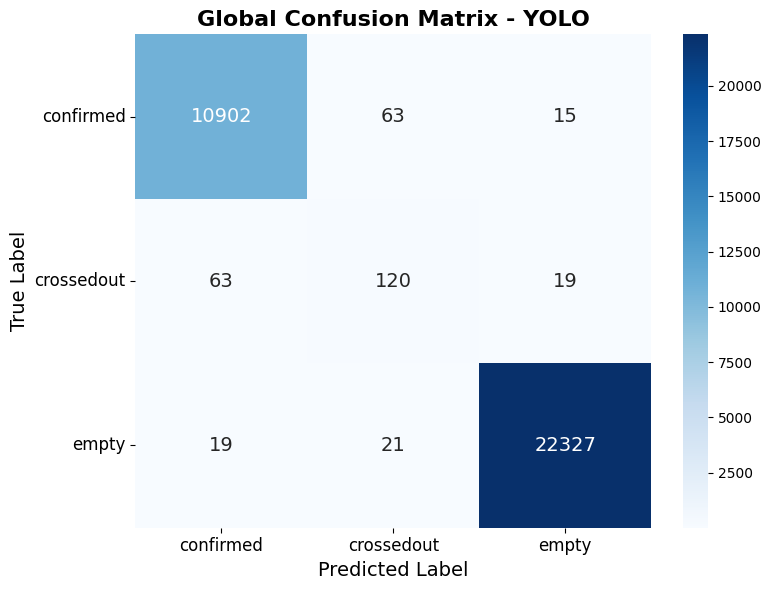

✅ Đã lưu ảnh ma trận nhầm lẫn tại 'global_confusion_matrix_yolo.png'


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from ultralytics import YOLO

# =============================================================================
# 1. CẤU HÌNH ĐÁNH GIÁ (BẠN CHỈ CHỈNH SỬA PHẦN NÀY)
# =============================================================================
# Lựa chọn mô hình muốn đánh giá: 'efficientnet', 'resnet50', hoặc 'yolo'
MODEL_TO_TEST = 'yolo'

# Thư mục gốc chứa 5 Fold (Bên trong là Fold_1, Fold_2... và mục con 'val' hoặc 'test')
BASE_FOLDS_DIR = "/content/content/OMR_5Fold_ROIs_split"
TEST_FOLDER_NAME = "test" # Đổi thành 'test' nếu lúc chia dữ liệu bạn đặt tên là test
W_DIR = "/content/drive/MyDrive/OMR-Datasets/train-cls/scene2/Yolo26s_v1"

CLASS_NAMES = ['confirmed', 'crossedout', 'empty'] # Đảm bảo đúng chuẩn Alphabet
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# =============================================================================
# 2. ĐỊNH NGHĨA TIỀN XỬ LÝ (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, (255, 255, 255), 'constant')

data_transforms = transforms.Compose([
    SquarePad(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# =============================================================================
# 3. HÀM KHỞI TẠO MÔ HÌNH (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
def get_efficientnet_model():
    model = models.efficientnet_b0(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

def get_resnet50_model():
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

# =============================================================================
# 4. VÒNG LẶP ĐÁNH GIÁ 5 FOLD CHÍNH
# =============================================================================
def evaluate_all_folds():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: {MODEL_TO_TEST.upper()} TRÊN 5 FOLDS")

    fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    global_y_true = []
    global_y_pred = []

    for fold in range(1, 6):
        print(f"\n[{'='*20} ĐÁNH GIÁ FOLD {fold} {'='*20}]")

        fold_dir = os.path.join(BASE_FOLDS_DIR, f"Fold_{fold}")
        test_dir = os.path.join(fold_dir, TEST_FOLDER_NAME)
        weight_dir = os.path.join(W_DIR, f"Fold_{fold}")

        if not os.path.exists(test_dir):
            print(f"❌ Không tìm thấy dữ liệu Test tại {test_dir}. Bỏ qua Fold {fold}.")
            continue

        y_true_fold = []
        y_pred_fold = []

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO PYTORCH (EfficientNet & ResNet50)
        # ---------------------------------------------------------
        if MODEL_TO_TEST in ['efficientnet', 'resnet50']:
            # Lấy đường dẫn trọng số tốt nhất của Fold này
            # (Bạn sửa lại tên file trọng số cho khớp với lúc bạn lưu nhé)
            weight_name = f"{MODEL_TO_TEST}_b0_fold{fold}.pth"
            # weight_name = f"{MODEL_TO_TEST}_fold{fold}.pth"
            weight_path = os.path.join(weight_dir, weight_name)

            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy trọng số tại {weight_path}.")
                continue

            # Khởi tạo mô hình
            if MODEL_TO_TEST == 'efficientnet':
                model = get_efficientnet_model()
            else:
                model = get_resnet50_model()

            model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()

            # Load dữ liệu
            test_dataset = datasets.ImageFolder(test_dir, data_transforms)
            test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

            # Inference
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(DEVICE)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    y_true_fold.extend(labels.cpu().numpy())
                    y_pred_fold.extend(preds.cpu().numpy())

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO YOLOv8-cls
        # ---------------------------------------------------------
        elif MODEL_TO_TEST == 'yolo':
            weight_path = os.path.join(weight_dir, "weights", "best.pt")
            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy YOLO model tại {weight_path}.")
                continue

            model = YOLO(weight_path)

            # Dùng ImageFolder để đọc toàn bộ đường dẫn ảnh và nhãn thực tế một cách chuẩn xác
            test_dataset = datasets.ImageFolder(test_dir)

            for img_path, label_idx in test_dataset.samples:
                # YOLO tự động lo phần transform
                results = model(img_path, verbose=False)
                pred_idx = results[0].probs.top1 # Lấy index có xác suất cao nhất

                y_true_fold.append(label_idx)
                y_pred_fold.append(pred_idx)

        # ---------------------------------------------------------
        # TÍNH TOÁN CHỈ SỐ CỦA FOLD
        # ---------------------------------------------------------
        acc = accuracy_score(y_true_fold, y_pred_fold) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_fold, y_pred_fold, average='macro', zero_division=0
        )
        prec, rec, f1 = prec * 100, rec * 100, f1 * 100

        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)

        print(f"✅ Fold {fold} | Acc: {acc:.2f}% | Prec: {prec:.2f}% | Rec: {rec:.2f}% | F1: {f1:.2f}%")

        # Gom dữ liệu để đánh giá Global
        global_y_true.extend(y_true_fold)
        global_y_pred.extend(y_pred_fold)

    # =========================================================================
    # 5. XUẤT BÁO CÁO TỔNG KẾT & MA TRẬN NHẦM LẪN (DÀNH CHO BÀI BÁO)
    # =========================================================================
    if len(global_y_true) == 0:
        print("❌ Không có dữ liệu để đánh giá. Vui lòng kiểm tra lại đường dẫn.")
        return

    print(f"\n🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - {MODEL_TO_TEST.upper()} 🏆")
    print("=" * 60)
    print(f"Accuracy : {np.mean(fold_metrics['acc']):.2f}% ± {np.std(fold_metrics['acc']):.2f}%")
    print(f"Precision: {np.mean(fold_metrics['prec']):.2f}% ± {np.std(fold_metrics['prec']):.2f}%")
    print(f"Recall   : {np.mean(fold_metrics['rec']):.2f}% ± {np.std(fold_metrics['rec']):.2f}%")
    print(f"F1-Score : {np.mean(fold_metrics['f1']):.2f}% ± {np.std(fold_metrics['f1']):.2f}%")
    print("=" * 60)

    print("\n📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):")
    report = classification_report(global_y_true, global_y_pred, target_names=CLASS_NAMES, digits=4)
    print(report)

    # Vẽ và lưu Ma trận nhầm lẫn
    cm = confusion_matrix(global_y_true, global_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={"size": 14})

    plt.title(f'Global Confusion Matrix - {MODEL_TO_TEST.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)

    img_name = f'global_confusion_matrix_{MODEL_TO_TEST}.png'
    plt.tight_layout()
    plt.savefig(img_name, dpi=300) # Xuất ảnh 300 DPI cực nét
    plt.show()

    print(f"✅ Đã lưu ảnh ma trận nhầm lẫn tại '{img_name}'")

# Gọi hàm thực thi
if __name__ == '__main__':
    evaluate_all_folds()

# ResNet50

##Scene 1

🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: RESNET50 TRÊN 5 FOLDS

[==================== ĐÁNH GIÁ FOLD 1 ====================]
✅ Fold 1 | Acc: 96.64% | Prec: 70.25% | Rec: 87.41% | F1: 72.01%

[==================== ĐÁNH GIÁ FOLD 2 ====================]
✅ Fold 2 | Acc: 98.11% | Prec: 74.79% | Rec: 87.20% | F1: 78.10%

[==================== ĐÁNH GIÁ FOLD 3 ====================]
✅ Fold 3 | Acc: 97.24% | Prec: 70.61% | Rec: 84.86% | F1: 72.60%

[==================== ĐÁNH GIÁ FOLD 4 ====================]
✅ Fold 4 | Acc: 96.87% | Prec: 70.62% | Rec: 89.24% | F1: 72.77%

[==================== ĐÁNH GIÁ FOLD 5 ====================]
✅ Fold 5 | Acc: 97.99% | Prec: 73.69% | Rec: 89.56% | F1: 76.98%

🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - RESNET50 🏆
Accuracy : 97.37% ± 0.59%
Precision: 71.99% ± 1.87%
Recall   : 87.65% ± 1.69%
F1-Score : 74.49% ± 2.53%

📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):
              precision    recall  f1-score   support

   confirmed     0.9902    0.9546  

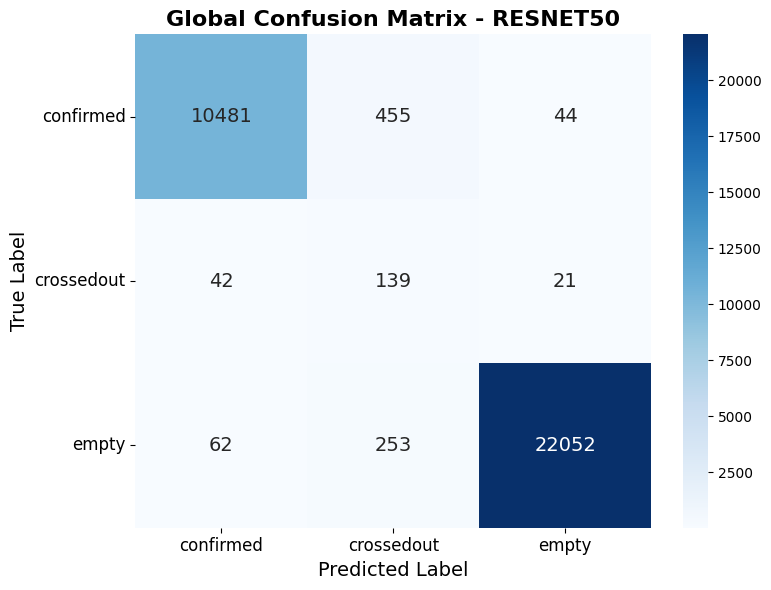

✅ Đã lưu ảnh ma trận nhầm lẫn tại 'global_confusion_matrix_resnet50.png'


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from ultralytics import YOLO

# =============================================================================
# 1. CẤU HÌNH ĐÁNH GIÁ (BẠN CHỈ CHỈNH SỬA PHẦN NÀY)
# =============================================================================
# Lựa chọn mô hình muốn đánh giá: 'efficientnet', 'resnet50', hoặc 'yolo'
MODEL_TO_TEST = 'resnet50'

# Thư mục gốc chứa 5 Fold (Bên trong là Fold_1, Fold_2... và mục con 'val' hoặc 'test')
BASE_FOLDS_DIR = "/content/content/OMR_5Fold_ROIs_split"
TEST_FOLDER_NAME = "test" # Đổi thành 'test' nếu lúc chia dữ liệu bạn đặt tên là test
W_DIR = "/content/drive/MyDrive/OMR-Datasets/train-cls/scene1/ResNet50"

CLASS_NAMES = ['confirmed', 'crossedout', 'empty'] # Đảm bảo đúng chuẩn Alphabet
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# =============================================================================
# 2. ĐỊNH NGHĨA TIỀN XỬ LÝ (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, (255, 255, 255), 'constant')

data_transforms = transforms.Compose([
    SquarePad(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# =============================================================================
# 3. HÀM KHỞI TẠO MÔ HÌNH (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
def get_efficientnet_model():
    model = models.efficientnet_b0(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

def get_resnet50_model():
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

# =============================================================================
# 4. VÒNG LẶP ĐÁNH GIÁ 5 FOLD CHÍNH
# =============================================================================
def evaluate_all_folds():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: {MODEL_TO_TEST.upper()} TRÊN 5 FOLDS")

    fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    global_y_true = []
    global_y_pred = []

    for fold in range(1, 6):
        print(f"\n[{'='*20} ĐÁNH GIÁ FOLD {fold} {'='*20}]")

        fold_dir = os.path.join(BASE_FOLDS_DIR, f"Fold_{fold}")
        test_dir = os.path.join(fold_dir, TEST_FOLDER_NAME)
        weight_dir = os.path.join(W_DIR, f"Fold_{fold}")

        if not os.path.exists(test_dir):
            print(f"❌ Không tìm thấy dữ liệu Test tại {test_dir}. Bỏ qua Fold {fold}.")
            continue

        y_true_fold = []
        y_pred_fold = []

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO PYTORCH (EfficientNet & ResNet50)
        # ---------------------------------------------------------
        if MODEL_TO_TEST in ['efficientnet', 'resnet50']:
            # Lấy đường dẫn trọng số tốt nhất của Fold này
            # (Bạn sửa lại tên file trọng số cho khớp với lúc bạn lưu nhé)
            # weight_name = f"{MODEL_TO_TEST}_b0_fold{fold}.pth"
            weight_name = f"{MODEL_TO_TEST}_fold{fold}.pth"
            weight_path = os.path.join(weight_dir, weight_name)

            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy trọng số tại {weight_path}.")
                continue

            # Khởi tạo mô hình
            if MODEL_TO_TEST == 'efficientnet':
                model = get_efficientnet_model()
            else:
                model = get_resnet50_model()

            model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()

            # Load dữ liệu
            test_dataset = datasets.ImageFolder(test_dir, data_transforms)
            test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

            # Inference
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(DEVICE)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    y_true_fold.extend(labels.cpu().numpy())
                    y_pred_fold.extend(preds.cpu().numpy())

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO YOLOv8-cls
        # ---------------------------------------------------------
        elif MODEL_TO_TEST == 'yolo':
            weight_path = os.path.join(weight_dir, "weights", "best.pt")
            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy YOLO model tại {weight_path}.")
                continue

            model = YOLO(weight_path)

            # Dùng ImageFolder để đọc toàn bộ đường dẫn ảnh và nhãn thực tế một cách chuẩn xác
            test_dataset = datasets.ImageFolder(test_dir)

            for img_path, label_idx in test_dataset.samples:
                # YOLO tự động lo phần transform
                results = model(img_path, verbose=False)
                pred_idx = results[0].probs.top1 # Lấy index có xác suất cao nhất

                y_true_fold.append(label_idx)
                y_pred_fold.append(pred_idx)

        # ---------------------------------------------------------
        # TÍNH TOÁN CHỈ SỐ CỦA FOLD
        # ---------------------------------------------------------
        acc = accuracy_score(y_true_fold, y_pred_fold) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_fold, y_pred_fold, average='macro', zero_division=0
        )
        prec, rec, f1 = prec * 100, rec * 100, f1 * 100

        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)

        print(f"✅ Fold {fold} | Acc: {acc:.2f}% | Prec: {prec:.2f}% | Rec: {rec:.2f}% | F1: {f1:.2f}%")

        # Gom dữ liệu để đánh giá Global
        global_y_true.extend(y_true_fold)
        global_y_pred.extend(y_pred_fold)

    # =========================================================================
    # 5. XUẤT BÁO CÁO TỔNG KẾT & MA TRẬN NHẦM LẪN (DÀNH CHO BÀI BÁO)
    # =========================================================================
    if len(global_y_true) == 0:
        print("❌ Không có dữ liệu để đánh giá. Vui lòng kiểm tra lại đường dẫn.")
        return

    print(f"\n🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - {MODEL_TO_TEST.upper()} 🏆")
    print("=" * 60)
    print(f"Accuracy : {np.mean(fold_metrics['acc']):.2f}% ± {np.std(fold_metrics['acc']):.2f}%")
    print(f"Precision: {np.mean(fold_metrics['prec']):.2f}% ± {np.std(fold_metrics['prec']):.2f}%")
    print(f"Recall   : {np.mean(fold_metrics['rec']):.2f}% ± {np.std(fold_metrics['rec']):.2f}%")
    print(f"F1-Score : {np.mean(fold_metrics['f1']):.2f}% ± {np.std(fold_metrics['f1']):.2f}%")
    print("=" * 60)

    print("\n📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):")
    report = classification_report(global_y_true, global_y_pred, target_names=CLASS_NAMES, digits=4)
    print(report)

    # Vẽ và lưu Ma trận nhầm lẫn
    cm = confusion_matrix(global_y_true, global_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={"size": 14})

    plt.title(f'Global Confusion Matrix - {MODEL_TO_TEST.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)

    img_name = f'global_confusion_matrix_{MODEL_TO_TEST}.png'
    plt.tight_layout()
    plt.savefig(img_name, dpi=300) # Xuất ảnh 300 DPI cực nét
    plt.show()

    print(f"✅ Đã lưu ảnh ma trận nhầm lẫn tại '{img_name}'")

# Gọi hàm thực thi
if __name__ == '__main__':
    evaluate_all_folds()

##Scene 2

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from ultralytics import YOLO

# =============================================================================
# 1. CẤU HÌNH ĐÁNH GIÁ (BẠN CHỈ CHỈNH SỬA PHẦN NÀY)
# =============================================================================
# Lựa chọn mô hình muốn đánh giá: 'efficientnet', 'resnet50', hoặc 'yolo'
MODEL_TO_TEST = 'resnet50'

# Thư mục gốc chứa 5 Fold (Bên trong là Fold_1, Fold_2... và mục con 'val' hoặc 'test')
BASE_FOLDS_DIR = "/content/content/OMR_5Fold_ROIs_split"
TEST_FOLDER_NAME = "test" # Đổi thành 'test' nếu lúc chia dữ liệu bạn đặt tên là test
W_DIR = "/content/drive/MyDrive/OMR-Datasets/train-cls/scene2/ResNet50"

CLASS_NAMES = ['confirmed', 'crossedout', 'empty'] # Đảm bảo đúng chuẩn Alphabet
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# =============================================================================
# 2. ĐỊNH NGHĨA TIỀN XỬ LÝ (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, (255, 255, 255), 'constant')

data_transforms = transforms.Compose([
    SquarePad(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# =============================================================================
# 3. HÀM KHỞI TẠO MÔ HÌNH (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
def get_efficientnet_model():
    model = models.efficientnet_b0(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

def get_resnet50_model():
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

# =============================================================================
# 4. VÒNG LẶP ĐÁNH GIÁ 5 FOLD CHÍNH
# =============================================================================
def evaluate_all_folds():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: {MODEL_TO_TEST.upper()} TRÊN 5 FOLDS")

    fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    global_y_true = []
    global_y_pred = []

    for fold in range(1, 6):
        print(f"\n[{'='*20} ĐÁNH GIÁ FOLD {fold} {'='*20}]")

        fold_dir = os.path.join(BASE_FOLDS_DIR, f"Fold_{fold}")
        test_dir = os.path.join(fold_dir, TEST_FOLDER_NAME)
        weight_dir = os.path.join(W_DIR, f"Fold_{fold}")

        if not os.path.exists(test_dir):
            print(f"❌ Không tìm thấy dữ liệu Test tại {test_dir}. Bỏ qua Fold {fold}.")
            continue

        y_true_fold = []
        y_pred_fold = []

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO PYTORCH (EfficientNet & ResNet50)
        # ---------------------------------------------------------
        if MODEL_TO_TEST in ['efficientnet', 'resnet50']:
            # Lấy đường dẫn trọng số tốt nhất của Fold này
            # (Bạn sửa lại tên file trọng số cho khớp với lúc bạn lưu nhé)
            # weight_name = f"{MODEL_TO_TEST}_b0_fold{fold}.pth"
            weight_name = f"{MODEL_TO_TEST}_fold{fold}.pth"
            weight_path = os.path.join(weight_dir, weight_name)

            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy trọng số tại {weight_path}.")
                continue

            # Khởi tạo mô hình
            if MODEL_TO_TEST == 'efficientnet':
                model = get_efficientnet_model()
            else:
                model = get_resnet50_model()

            model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()

            # Load dữ liệu
            test_dataset = datasets.ImageFolder(test_dir, data_transforms)
            test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

            # Inference
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(DEVICE)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    y_true_fold.extend(labels.cpu().numpy())
                    y_pred_fold.extend(preds.cpu().numpy())

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO YOLOv8-cls
        # ---------------------------------------------------------
        elif MODEL_TO_TEST == 'yolo':
            weight_path = os.path.join(weight_dir, "weights", "best.pt")
            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy YOLO model tại {weight_path}.")
                continue

            model = YOLO(weight_path)

            # Dùng ImageFolder để đọc toàn bộ đường dẫn ảnh và nhãn thực tế một cách chuẩn xác
            test_dataset = datasets.ImageFolder(test_dir)

            for img_path, label_idx in test_dataset.samples:
                # YOLO tự động lo phần transform
                results = model(img_path, verbose=False)
                pred_idx = results[0].probs.top1 # Lấy index có xác suất cao nhất

                y_true_fold.append(label_idx)
                y_pred_fold.append(pred_idx)

        # ---------------------------------------------------------
        # TÍNH TOÁN CHỈ SỐ CỦA FOLD
        # ---------------------------------------------------------
        acc = accuracy_score(y_true_fold, y_pred_fold) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_fold, y_pred_fold, average='macro', zero_division=0
        )
        prec, rec, f1 = prec * 100, rec * 100, f1 * 100

        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)

        print(f"✅ Fold {fold} | Acc: {acc:.2f}% | Prec: {prec:.2f}% | Rec: {rec:.2f}% | F1: {f1:.2f}%")

        # Gom dữ liệu để đánh giá Global
        global_y_true.extend(y_true_fold)
        global_y_pred.extend(y_pred_fold)

    # =========================================================================
    # 5. XUẤT BÁO CÁO TỔNG KẾT & MA TRẬN NHẦM LẪN (DÀNH CHO BÀI BÁO)
    # =========================================================================
    if len(global_y_true) == 0:
        print("❌ Không có dữ liệu để đánh giá. Vui lòng kiểm tra lại đường dẫn.")
        return

    print(f"\n🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - {MODEL_TO_TEST.upper()} 🏆")
    print("=" * 60)
    print(f"Accuracy : {np.mean(fold_metrics['acc']):.2f}% ± {np.std(fold_metrics['acc']):.2f}%")
    print(f"Precision: {np.mean(fold_metrics['prec']):.2f}% ± {np.std(fold_metrics['prec']):.2f}%")
    print(f"Recall   : {np.mean(fold_metrics['rec']):.2f}% ± {np.std(fold_metrics['rec']):.2f}%")
    print(f"F1-Score : {np.mean(fold_metrics['f1']):.2f}% ± {np.std(fold_metrics['f1']):.2f}%")
    print("=" * 60)

    print("\n📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):")
    report = classification_report(global_y_true, global_y_pred, target_names=CLASS_NAMES, digits=4)
    print(report)

    # Vẽ và lưu Ma trận nhầm lẫn
    cm = confusion_matrix(global_y_true, global_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={"size": 14})

    plt.title(f'Global Confusion Matrix - {MODEL_TO_TEST.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)

    img_name = f'global_confusion_matrix_{MODEL_TO_TEST}.png'
    plt.tight_layout()
    plt.savefig(img_name, dpi=300) # Xuất ảnh 300 DPI cực nét
    plt.show()

    print(f"✅ Đã lưu ảnh ma trận nhầm lẫn tại '{img_name}'")

# Gọi hàm thực thi
if __name__ == '__main__':
    evaluate_all_folds()

🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: RESNET50 TRÊN 5 FOLDS

[==================== ĐÁNH GIÁ FOLD 1 ====================]
❌ Không tìm thấy trọng số tại /content/drive/MyDrive/OMR-Datasets/train-cls/scene2/ResNet50/Fold_1/resnet50_fold1.pth.

[==================== ĐÁNH GIÁ FOLD 2 ====================]
❌ Không tìm thấy trọng số tại /content/drive/MyDrive/OMR-Datasets/train-cls/scene2/ResNet50/Fold_2/resnet50_fold2.pth.

[==================== ĐÁNH GIÁ FOLD 3 ====================]
❌ Không tìm thấy trọng số tại /content/drive/MyDrive/OMR-Datasets/train-cls/scene2/ResNet50/Fold_3/resnet50_fold3.pth.

[==================== ĐÁNH GIÁ FOLD 4 ====================]
❌ Không tìm thấy trọng số tại /content/drive/MyDrive/OMR-Datasets/train-cls/scene2/ResNet50/Fold_4/resnet50_fold4.pth.

[==================== ĐÁNH GIÁ FOLD 5 ====================]
❌ Không tìm thấy trọng số tại /content/drive/MyDrive/OMR-Datasets/train-cls/scene2/ResNet50/Fold_5/resnet50_fold5.pth.
❌ Không có dữ liệu để đánh giá. Vui lòng kiểm tra 

#EfficientNetB0

##Scene 1

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from ultralytics import YOLO

# =============================================================================
# 1. CẤU HÌNH ĐÁNH GIÁ (BẠN CHỈ CHỈNH SỬA PHẦN NÀY)
# =============================================================================
# Lựa chọn mô hình muốn đánh giá: 'efficientnet', 'resnet50', hoặc 'yolo'
MODEL_TO_TEST = 'resnet50'

# Thư mục gốc chứa 5 Fold (Bên trong là Fold_1, Fold_2... và mục con 'val' hoặc 'test')
BASE_FOLDS_DIR = "/content/content/OMR_5Fold_ROIs_split"
TEST_FOLDER_NAME = "test" # Đổi thành 'test' nếu lúc chia dữ liệu bạn đặt tên là test
W_DIR = "/content/drive/MyDrive/OMR-Datasets/train-cls/scene1/ResNet50"

CLASS_NAMES = ['confirmed', 'crossedout', 'empty'] # Đảm bảo đúng chuẩn Alphabet
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# =============================================================================
# 2. ĐỊNH NGHĨA TIỀN XỬ LÝ (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, (255, 255, 255), 'constant')

data_transforms = transforms.Compose([
    SquarePad(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# =============================================================================
# 3. HÀM KHỞI TẠO MÔ HÌNH (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
def get_efficientnet_model():
    model = models.efficientnet_b0(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

def get_resnet50_model():
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

# =============================================================================
# 4. VÒNG LẶP ĐÁNH GIÁ 5 FOLD CHÍNH
# =============================================================================
def evaluate_all_folds():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: {MODEL_TO_TEST.upper()} TRÊN 5 FOLDS")

    fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    global_y_true = []
    global_y_pred = []

    for fold in range(1, 6):
        print(f"\n[{'='*20} ĐÁNH GIÁ FOLD {fold} {'='*20}]")

        fold_dir = os.path.join(BASE_FOLDS_DIR, f"Fold_{fold}")
        test_dir = os.path.join(fold_dir, TEST_FOLDER_NAME)
        weight_dir = os.path.join(W_DIR, f"Fold_{fold}")

        if not os.path.exists(test_dir):
            print(f"❌ Không tìm thấy dữ liệu Test tại {test_dir}. Bỏ qua Fold {fold}.")
            continue

        y_true_fold = []
        y_pred_fold = []

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO PYTORCH (EfficientNet & ResNet50)
        # ---------------------------------------------------------
        if MODEL_TO_TEST in ['efficientnet', 'resnet50']:
            # Lấy đường dẫn trọng số tốt nhất của Fold này
            # (Bạn sửa lại tên file trọng số cho khớp với lúc bạn lưu nhé)
            # weight_name = f"{MODEL_TO_TEST}_b0_fold{fold}.pth"
            weight_name = f"{MODEL_TO_TEST}_fold{fold}.pth"
            weight_path = os.path.join(weight_dir, weight_name)

            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy trọng số tại {weight_path}.")
                continue

            # Khởi tạo mô hình
            if MODEL_TO_TEST == 'efficientnet':
                model = get_efficientnet_model()
            else:
                model = get_resnet50_model()

            model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()

            # Load dữ liệu
            test_dataset = datasets.ImageFolder(test_dir, data_transforms)
            test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

            # Inference
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(DEVICE)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    y_true_fold.extend(labels.cpu().numpy())
                    y_pred_fold.extend(preds.cpu().numpy())

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO YOLOv8-cls
        # ---------------------------------------------------------
        elif MODEL_TO_TEST == 'yolo':
            weight_path = os.path.join(weight_dir, "weights", "best.pt")
            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy YOLO model tại {weight_path}.")
                continue

            model = YOLO(weight_path)

            # Dùng ImageFolder để đọc toàn bộ đường dẫn ảnh và nhãn thực tế một cách chuẩn xác
            test_dataset = datasets.ImageFolder(test_dir)

            for img_path, label_idx in test_dataset.samples:
                # YOLO tự động lo phần transform
                results = model(img_path, verbose=False)
                pred_idx = results[0].probs.top1 # Lấy index có xác suất cao nhất

                y_true_fold.append(label_idx)
                y_pred_fold.append(pred_idx)

        # ---------------------------------------------------------
        # TÍNH TOÁN CHỈ SỐ CỦA FOLD
        # ---------------------------------------------------------
        acc = accuracy_score(y_true_fold, y_pred_fold) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_fold, y_pred_fold, average='macro', zero_division=0
        )
        prec, rec, f1 = prec * 100, rec * 100, f1 * 100

        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)

        print(f"✅ Fold {fold} | Acc: {acc:.2f}% | Prec: {prec:.2f}% | Rec: {rec:.2f}% | F1: {f1:.2f}%")

        # Gom dữ liệu để đánh giá Global
        global_y_true.extend(y_true_fold)
        global_y_pred.extend(y_pred_fold)

    # =========================================================================
    # 5. XUẤT BÁO CÁO TỔNG KẾT & MA TRẬN NHẦM LẪN (DÀNH CHO BÀI BÁO)
    # =========================================================================
    if len(global_y_true) == 0:
        print("❌ Không có dữ liệu để đánh giá. Vui lòng kiểm tra lại đường dẫn.")
        return

    print(f"\n🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - {MODEL_TO_TEST.upper()} 🏆")
    print("=" * 60)
    print(f"Accuracy : {np.mean(fold_metrics['acc']):.2f}% ± {np.std(fold_metrics['acc']):.2f}%")
    print(f"Precision: {np.mean(fold_metrics['prec']):.2f}% ± {np.std(fold_metrics['prec']):.2f}%")
    print(f"Recall   : {np.mean(fold_metrics['rec']):.2f}% ± {np.std(fold_metrics['rec']):.2f}%")
    print(f"F1-Score : {np.mean(fold_metrics['f1']):.2f}% ± {np.std(fold_metrics['f1']):.2f}%")
    print("=" * 60)

    print("\n📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):")
    report = classification_report(global_y_true, global_y_pred, target_names=CLASS_NAMES, digits=4)
    print(report)

    # Vẽ và lưu Ma trận nhầm lẫn
    cm = confusion_matrix(global_y_true, global_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={"size": 14})

    plt.title(f'Global Confusion Matrix - {MODEL_TO_TEST.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)

    img_name = f'global_confusion_matrix_{MODEL_TO_TEST}.png'
    plt.tight_layout()
    plt.savefig(img_name, dpi=300) # Xuất ảnh 300 DPI cực nét
    plt.show()

    print(f"✅ Đã lưu ảnh ma trận nhầm lẫn tại '{img_name}'")

# Gọi hàm thực thi
if __name__ == '__main__':
    evaluate_all_folds()

##Scene 2

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)
from ultralytics import YOLO

# =============================================================================
# 1. CẤU HÌNH ĐÁNH GIÁ (BẠN CHỈ CHỈNH SỬA PHẦN NÀY)
# =============================================================================
# Lựa chọn mô hình muốn đánh giá: 'efficientnet', 'resnet50', hoặc 'yolo'
MODEL_TO_TEST = 'resnet50'

# Thư mục gốc chứa 5 Fold (Bên trong là Fold_1, Fold_2... và mục con 'val' hoặc 'test')
BASE_FOLDS_DIR = "/content/content/OMR_5Fold_ROIs_split"
TEST_FOLDER_NAME = "test" # Đổi thành 'test' nếu lúc chia dữ liệu bạn đặt tên là test
W_DIR = "/content/drive/MyDrive/OMR-Datasets/train-cls/scene2/ResNet50"

CLASS_NAMES = ['confirmed', 'crossedout', 'empty'] # Đảm bảo đúng chuẩn Alphabet
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# =============================================================================
# 2. ĐỊNH NGHĨA TIỀN XỬ LÝ (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = np.max([w, h])
        hp = int((max_wh - w) / 2)
        vp = int((max_wh - h) / 2)
        padding = (hp, vp, hp, vp)
        return F.pad(image, padding, (255, 255, 255), 'constant')

data_transforms = transforms.Compose([
    SquarePad(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# =============================================================================
# 3. HÀM KHỞI TẠO MÔ HÌNH (GIỐNG HỆT LÚC TRAIN)
# =============================================================================
def get_efficientnet_model():
    model = models.efficientnet_b0(weights=None)
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

def get_resnet50_model():
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
    return model

# =============================================================================
# 4. VÒNG LẶP ĐÁNH GIÁ 5 FOLD CHÍNH
# =============================================================================
def evaluate_all_folds():
    print(f"🚀 BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH: {MODEL_TO_TEST.upper()} TRÊN 5 FOLDS")

    fold_metrics = {'acc': [], 'prec': [], 'rec': [], 'f1': []}
    global_y_true = []
    global_y_pred = []

    for fold in range(1, 6):
        print(f"\n[{'='*20} ĐÁNH GIÁ FOLD {fold} {'='*20}]")

        fold_dir = os.path.join(BASE_FOLDS_DIR, f"Fold_{fold}")
        test_dir = os.path.join(fold_dir, TEST_FOLDER_NAME)
        weight_dir = os.path.join(W_DIR, f"Fold_{fold}")

        if not os.path.exists(test_dir):
            print(f"❌ Không tìm thấy dữ liệu Test tại {test_dir}. Bỏ qua Fold {fold}.")
            continue

        y_true_fold = []
        y_pred_fold = []

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO PYTORCH (EfficientNet & ResNet50)
        # ---------------------------------------------------------
        if MODEL_TO_TEST in ['efficientnet', 'resnet50']:
            # Lấy đường dẫn trọng số tốt nhất của Fold này
            # (Bạn sửa lại tên file trọng số cho khớp với lúc bạn lưu nhé)
            # weight_name = f"{MODEL_TO_TEST}_b0_fold{fold}.pth"
            weight_name = f"{MODEL_TO_TEST}_fold{fold}.pth"
            weight_path = os.path.join(weight_dir, weight_name)

            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy trọng số tại {weight_path}.")
                continue

            # Khởi tạo mô hình
            if MODEL_TO_TEST == 'efficientnet':
                model = get_efficientnet_model()
            else:
                model = get_resnet50_model()

            model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
            model.to(DEVICE)
            model.eval()

            # Load dữ liệu
            test_dataset = datasets.ImageFolder(test_dir, data_transforms)
            test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

            # Inference
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs = inputs.to(DEVICE)
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)

                    y_true_fold.extend(labels.cpu().numpy())
                    y_pred_fold.extend(preds.cpu().numpy())

        # ---------------------------------------------------------
        # LUỒNG ĐÁNH GIÁ CHO YOLOv8-cls
        # ---------------------------------------------------------
        elif MODEL_TO_TEST == 'yolo':
            weight_path = os.path.join(weight_dir, "weights", "best.pt")
            if not os.path.exists(weight_path):
                print(f"❌ Không tìm thấy YOLO model tại {weight_path}.")
                continue

            model = YOLO(weight_path)

            # Dùng ImageFolder để đọc toàn bộ đường dẫn ảnh và nhãn thực tế một cách chuẩn xác
            test_dataset = datasets.ImageFolder(test_dir)

            for img_path, label_idx in test_dataset.samples:
                # YOLO tự động lo phần transform
                results = model(img_path, verbose=False)
                pred_idx = results[0].probs.top1 # Lấy index có xác suất cao nhất

                y_true_fold.append(label_idx)
                y_pred_fold.append(pred_idx)

        # ---------------------------------------------------------
        # TÍNH TOÁN CHỈ SỐ CỦA FOLD
        # ---------------------------------------------------------
        acc = accuracy_score(y_true_fold, y_pred_fold) * 100
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_true_fold, y_pred_fold, average='macro', zero_division=0
        )
        prec, rec, f1 = prec * 100, rec * 100, f1 * 100

        fold_metrics['acc'].append(acc)
        fold_metrics['prec'].append(prec)
        fold_metrics['rec'].append(rec)
        fold_metrics['f1'].append(f1)

        print(f"✅ Fold {fold} | Acc: {acc:.2f}% | Prec: {prec:.2f}% | Rec: {rec:.2f}% | F1: {f1:.2f}%")

        # Gom dữ liệu để đánh giá Global
        global_y_true.extend(y_true_fold)
        global_y_pred.extend(y_pred_fold)

    # =========================================================================
    # 5. XUẤT BÁO CÁO TỔNG KẾT & MA TRẬN NHẦM LẪN (DÀNH CHO BÀI BÁO)
    # =========================================================================
    if len(global_y_true) == 0:
        print("❌ Không có dữ liệu để đánh giá. Vui lòng kiểm tra lại đường dẫn.")
        return

    print(f"\n🏆 TỔNG KẾT TRUNG BÌNH 5 FOLD (MEAN ± STD) - {MODEL_TO_TEST.upper()} 🏆")
    print("=" * 60)
    print(f"Accuracy : {np.mean(fold_metrics['acc']):.2f}% ± {np.std(fold_metrics['acc']):.2f}%")
    print(f"Precision: {np.mean(fold_metrics['prec']):.2f}% ± {np.std(fold_metrics['prec']):.2f}%")
    print(f"Recall   : {np.mean(fold_metrics['rec']):.2f}% ± {np.std(fold_metrics['rec']):.2f}%")
    print(f"F1-Score : {np.mean(fold_metrics['f1']):.2f}% ± {np.std(fold_metrics['f1']):.2f}%")
    print("=" * 60)

    print("\n📊 BÁO CÁO CHI TIẾT TRÊN TỪNG LỚP (GỘP TỪ TẤT CẢ 5 FOLD UNSEEN DATA):")
    report = classification_report(global_y_true, global_y_pred, target_names=CLASS_NAMES, digits=4)
    print(report)

    # Vẽ và lưu Ma trận nhầm lẫn
    cm = confusion_matrix(global_y_true, global_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                annot_kws={"size": 14})

    plt.title(f'Global Confusion Matrix - {MODEL_TO_TEST.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=14)
    plt.ylabel('True Label', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12, rotation=0)

    img_name = f'global_confusion_matrix_{MODEL_TO_TEST}.png'
    plt.tight_layout()
    plt.savefig(img_name, dpi=300) # Xuất ảnh 300 DPI cực nét
    plt.show()

    print(f"✅ Đã lưu ảnh ma trận nhầm lẫn tại '{img_name}'")

# Gọi hàm thực thi
if __name__ == '__main__':
    evaluate_all_folds()